# 海龟交易策略回测 — 兆易创新(603986)

## 策略简介

**海龟策略 (Turtle Trading System)** 由 Richard Dennis 和 William Eckhardt 于 1983 年创立，
是趋势跟踪策略的经典代表。

### 核心要素
| 要素 | 规则 |
|------|------|
| **入场** | 当日最高价突破过去 N 日高点 (唐奇安通道上轨) → 开仓 |
| **头寸** | 1 单位 = 账户 1% ÷ N 值 |
| **加仓** | 价格每涨 +0.5N 加 1 单位，最多 4 单位 |
| **止损** | 每单位入场价 - 2N |
| **退出** | 当日最低价跌破过去 M 日低点 (通道下轨) → 全部平仓 |

### 双系统
- **S1**: 20日突破入场 / 10日低点退出（敏感，抓短趋势）
- **S2**: 55日突破入场 / 20日低点退出（稳健，抓大趋势）

---
## 1. 导入依赖

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from turtle_strategy import TurtleStrategy
from turtle_backtest import TurtleBacktestEngine, PerformanceAnalyzer
from turtle_viz import (
    plot_price_channels_signals,
    plot_n_value_analysis,
    plot_position_units,
    plot_equity_curve,
    plot_wilder_atr,
)

print('✅ 导入成功')

✅ 导入成功


In [28]:
# 自动重载外部模块 (修改.py后无需重启内核)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## 2. 数据读取与预处理

In [29]:
df = pd.read_csv('../Task-3/兆易创新_daily.csv')
df['trade_date'] = pd.to_datetime(df['trade_date'])
df = df.sort_values('trade_date').reset_index(drop=True)

print(f"数据范围: {df['trade_date'].min()} ~ {df['trade_date'].max()}")
print(f"总交易日: {len(df)}")
print(f"股票代码: {df['ts_code'].iloc[0]}")
df.head()

数据范围: 2022-01-04 00:00:00 ~ 2026-07-08 00:00:00
总交易日: 1091
股票代码: 603986.SH


,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,603986.SH,2022-01-04,176.56,178.90,171.01,175.88,175.85,0.03,0.0171,108741.97,1900824.345
1,603986.SH,2022-01-05,174.77,174.77,158.29,158.30,175.88,-17.58,-9.9955,256634.97,4158864.709
2,603986.SH,2022-01-06,155.00,167.80,154.60,162.96,158.30,4.66,2.9438,164935.26,2658078.307
3,603986.SH,2022-01-07,161.01,163.98,156.63,157.00,162.96,-5.96,-3.6573,144878.99,2315062.079
4,603986.SH,2022-01-10,155.58,158.00,151.33,156.50,157.00,-0.50,-0.3185,99947.58,1550603.841


In [30]:
print('缺失值检查:')
print(df.isnull().sum())
print(f"\n价格区间: {df['close'].min():.2f} ~ {df['close'].max():.2f} 元")

缺失值检查:
ts_code       0
trade_date    0
open          0
high          0
low           0
close         0
pre_close     0
change        0
pct_chg       0
vol           0
amount        0
dtype: int64

价格区间: 57.92 ~ 840.00 元


---
## 3. S1 系统回测 (20日突破 / 10日退出)

In [31]:
strategy_s1 = TurtleStrategy(
    system='S1', entry_window=20, exit_window=10,
    atr_period=20, risk_pct=0.01, max_units=4, add_unit_step=0.5,
)
print(f'策略: {strategy_s1}')

策略: Turtle-S1(20x10)(entry=20, exit=10, atr=20, risk=0.01, max_units=4)


In [32]:
engine = TurtleBacktestEngine(
    initial_capital=1_000_000, commission_rate=0.0003,
    slippage=0.0001, stamp_duty=0.001, risk_pct=0.01,
)

trades_s1, equity_s1, units_s1 = engine.run(strategy_s1, df)

print(f"交易次数: {len(trades_s1)}")
print(f"最终权益: {equity_s1['equity'].iloc[-1]:,.2f} 元")

交易次数: 72
最终权益: 5,286,897.23 元


In [33]:
signal_df = strategy_s1.generate_signals(df)
cols = ['trade_date', 'close', 'n_value', 'channel_high', 'channel_low', 'signal']
signal_df[cols].tail(10)

,trade_date,close,n_value,channel_high,channel_low,signal
1081,2026-06-25,775.21,39.255985,705.09,471.00,1
1082,2026-06-26,770.00,39.617186,775.39,471.00,1
1083,2026-06-29,840.00,42.469326,779.00,476.66,1
1084,2026-06-30,815.00,43.290360,846.66,476.66,0
1085,2026-07-01,772.01,45.644842,846.66,517.71,0
1086,2026-07-02,694.81,47.222600,846.66,521.00,0
1087,2026-07-03,677.77,48.626970,846.66,586.60,0
1088,2026-07-06,654.29,49.445121,846.66,630.93,-1
1089,2026-07-07,620.00,49.337365,846.66,630.00,-1
1090,2026-07-08,603.17,49.470497,846.66,607.00,-1


---
## 4. S1 可视化

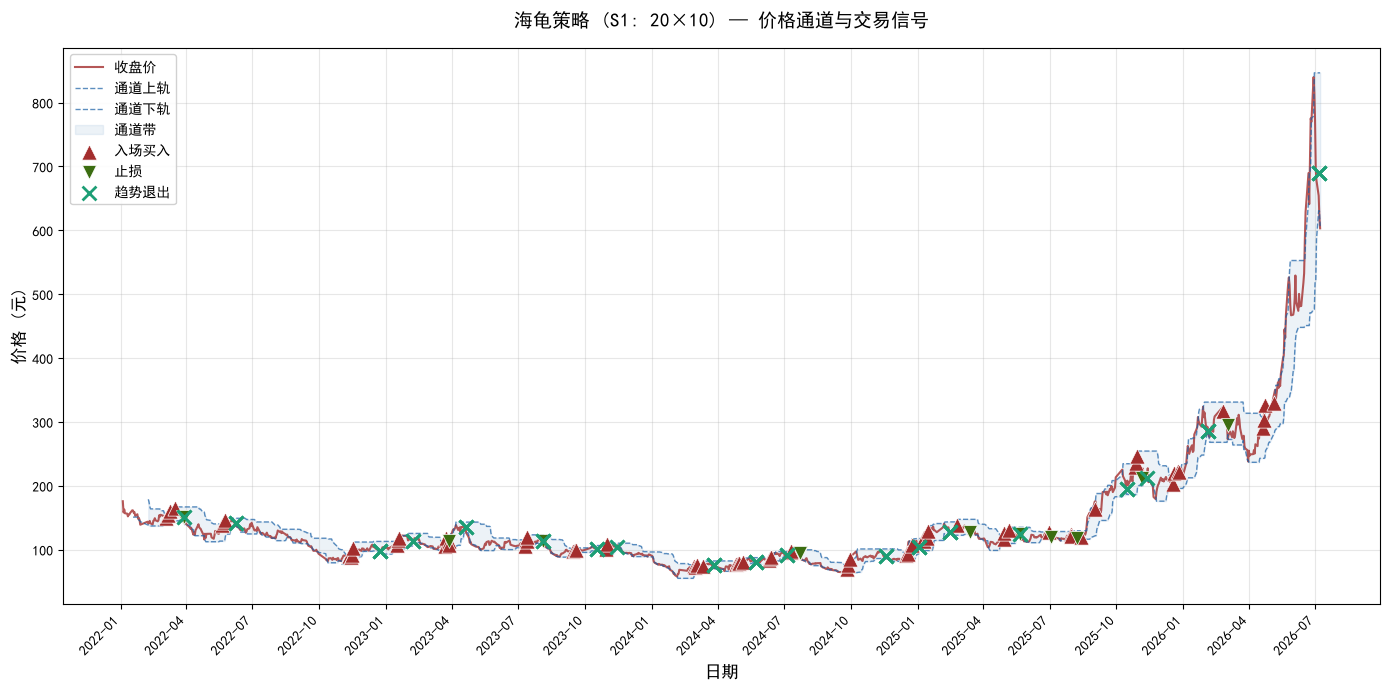

In [34]:
# 图1: 价格通道与交易信号
fig1 = plot_price_channels_signals(
    signal_df, trades_s1,
    title='海龟策略 (S1: 20×10) — 价格通道与交易信号'
)
plt.show()

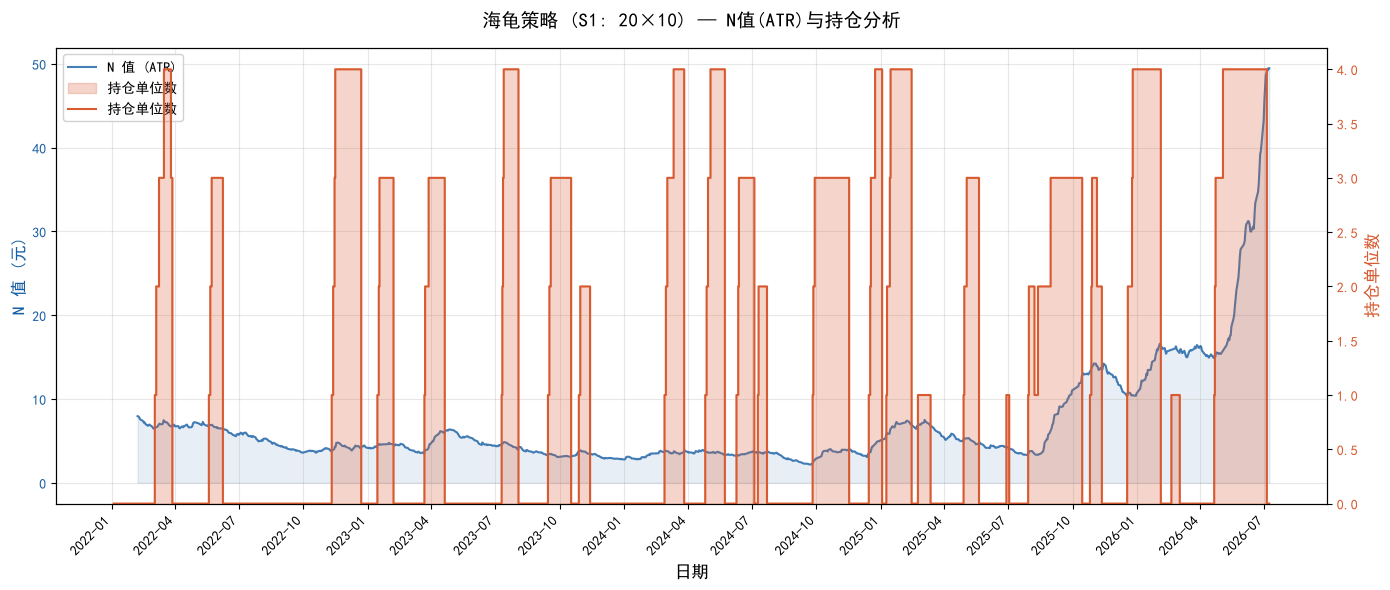

In [35]:
# 图2: N值(ATR)波动率曲线
fig2 = plot_n_value_analysis(
    signal_df, equity_s1,
    title='海龟策略 (S1: 20×10) — N值(ATR)与持仓分析'
)
plt.show()

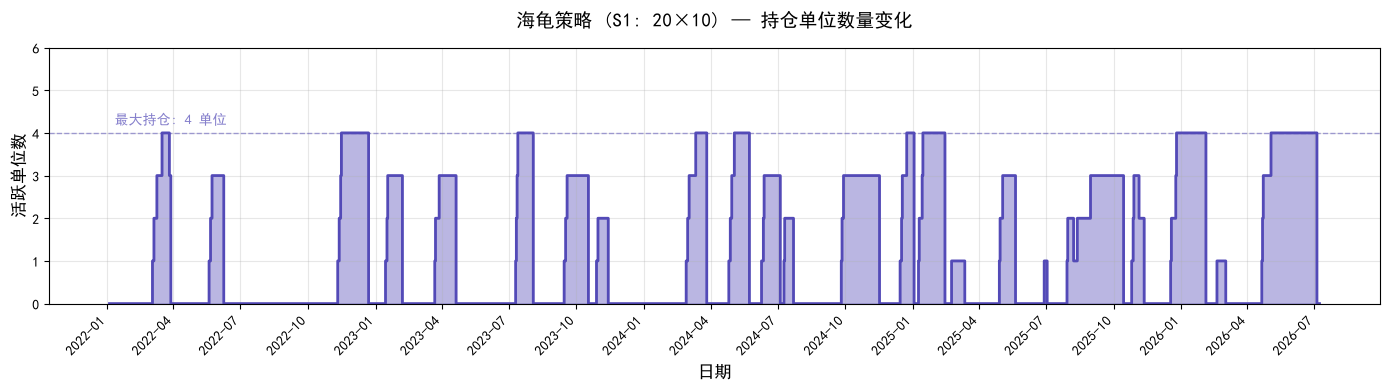

In [36]:
# 图3: 持仓单位数量变化
fig3 = plot_position_units(
    equity_s1,
    title='海龟策略 (S1: 20×10) — 持仓单位数量变化'
)
plt.show()

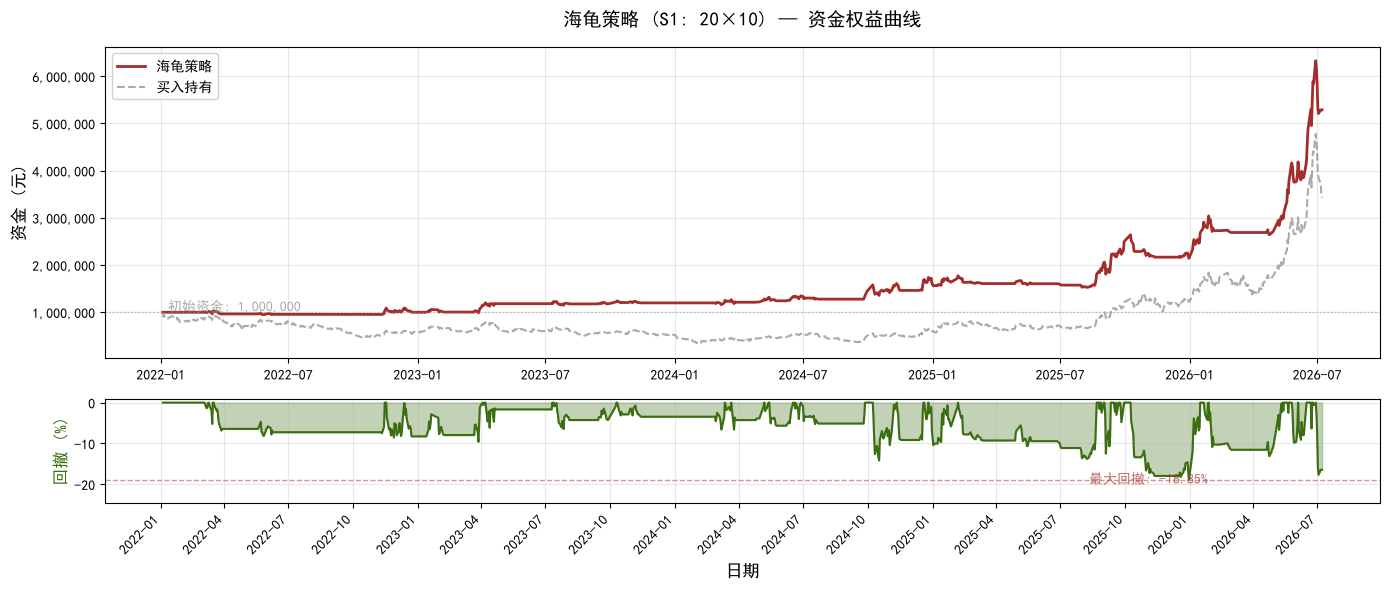

In [37]:
# 图4: 资金权益曲线 vs 买入持有基准
fig4 = plot_equity_curve(
    equity_s1, signal_df, initial_capital=1_000_000,
    title='海龟策略 (S1: 20×10) — 资金权益曲线'
)
plt.show()

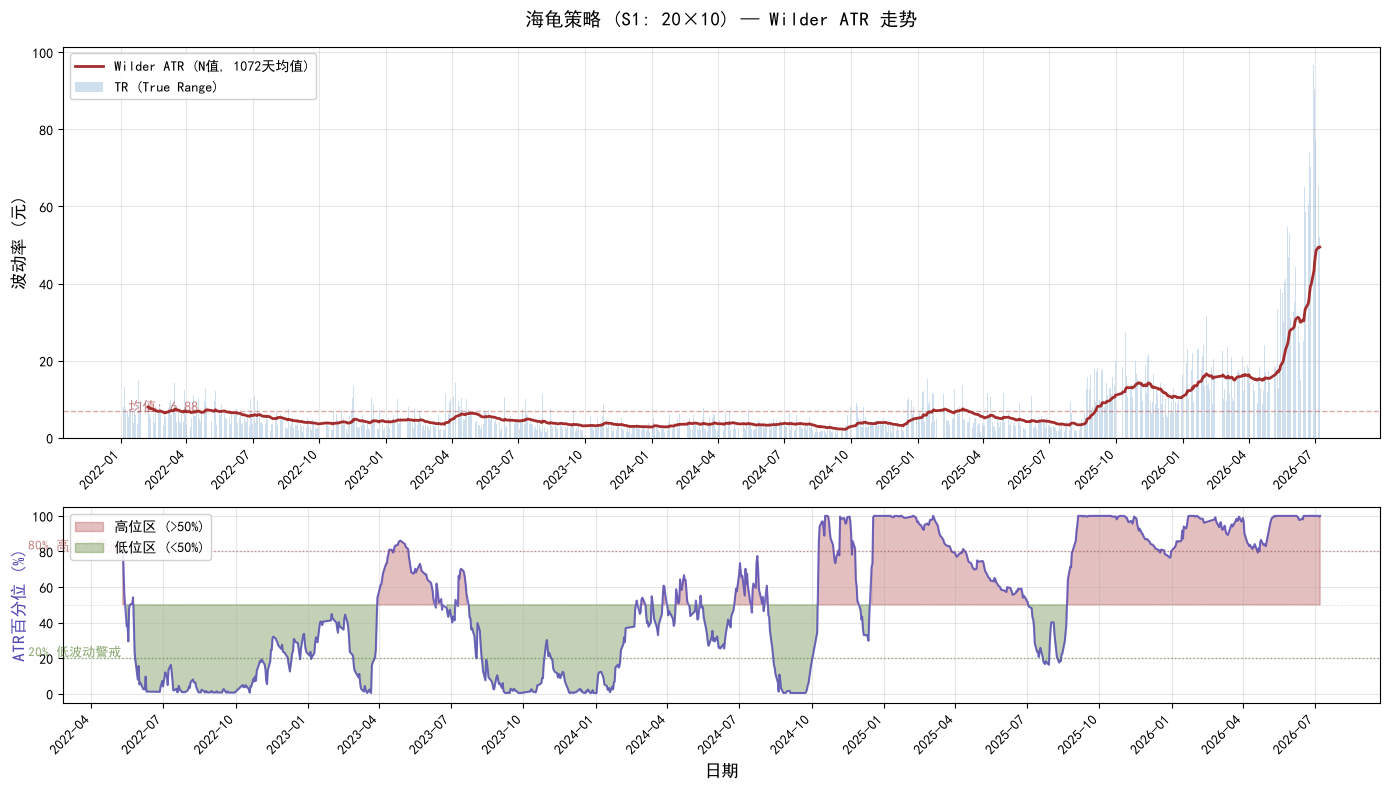

In [38]:
# 图5: Wilder ATR 走势
fig_s1_5 = plot_wilder_atr(
    signal_df,
    title='海龟策略 (S1: 20×10) — Wilder ATR 走势'
)
plt.show()

In [39]:
analyzer_s1 = PerformanceAnalyzer(equity_s1, trades_s1, initial_capital=1_000_000)
metrics_s1 = analyzer_s1.summary()

print('=' * 50)
print(' S1 系统绩效指标 (20日突破 / 10日退出)')
print('=' * 50)
for k, v in metrics_s1.items():
    print(f'  {k}: {v}')

 S1 系统绩效指标 (20日突破 / 10日退出)
  total_return: 428.69
  annual_return: 46.91
  max_drawdown: -18.85
  sharpe_ratio: 1.36
  total_trades: 72
  win_rate: 62.5
  avg_win: 105089.88
  avg_loss: 16375.82
  profit_factor: 10.7
  total_pnl: 4286897.22
  final_equity: 5286897.23
  stop_loss_trades: 12
  trend_exit_trades: 60
  force_liquidate_trades: 0


---
## 5. S2 系统回测 (55日突破 / 20日退出)

In [40]:
strategy_s2 = TurtleStrategy(
    system='S2', entry_window=55, exit_window=20,
    atr_period=20, risk_pct=0.01, max_units=4, add_unit_step=0.5,
)
print(f'策略: {strategy_s2}')

trades_s2, equity_s2, units_s2 = engine.run(strategy_s2, df)

print(f'\n交易次数: {len(trades_s2)}')
print(f"最终权益: {equity_s2['equity'].iloc[-1]:,.2f} 元")

策略: Turtle-S2(55x20)(entry=55, exit=20, atr=20, risk=0.01, max_units=4)

交易次数: 33
最终权益: 2,673,209.11 元


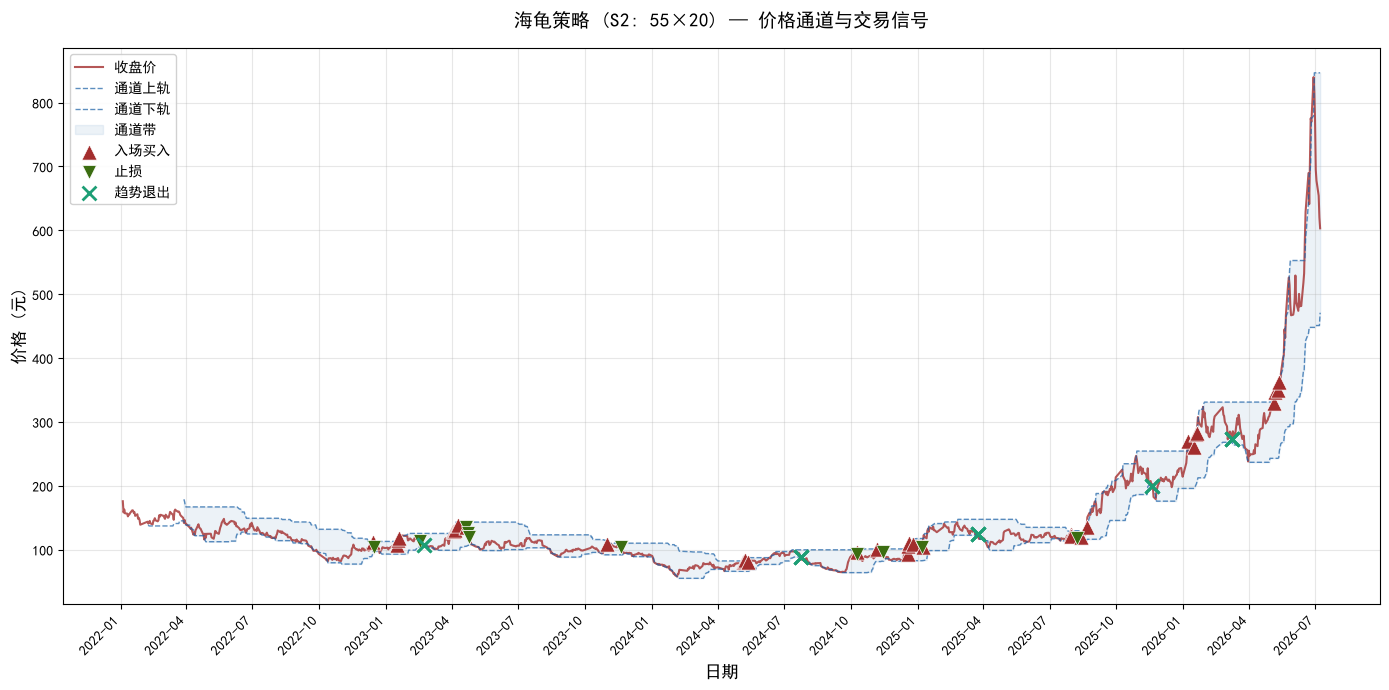

In [41]:
signal_df_s2 = strategy_s2.generate_signals(df)

fig_s2_1 = plot_price_channels_signals(
    signal_df_s2, trades_s2,
    title='海龟策略 (S2: 55×20) — 价格通道与交易信号'
)
plt.show()

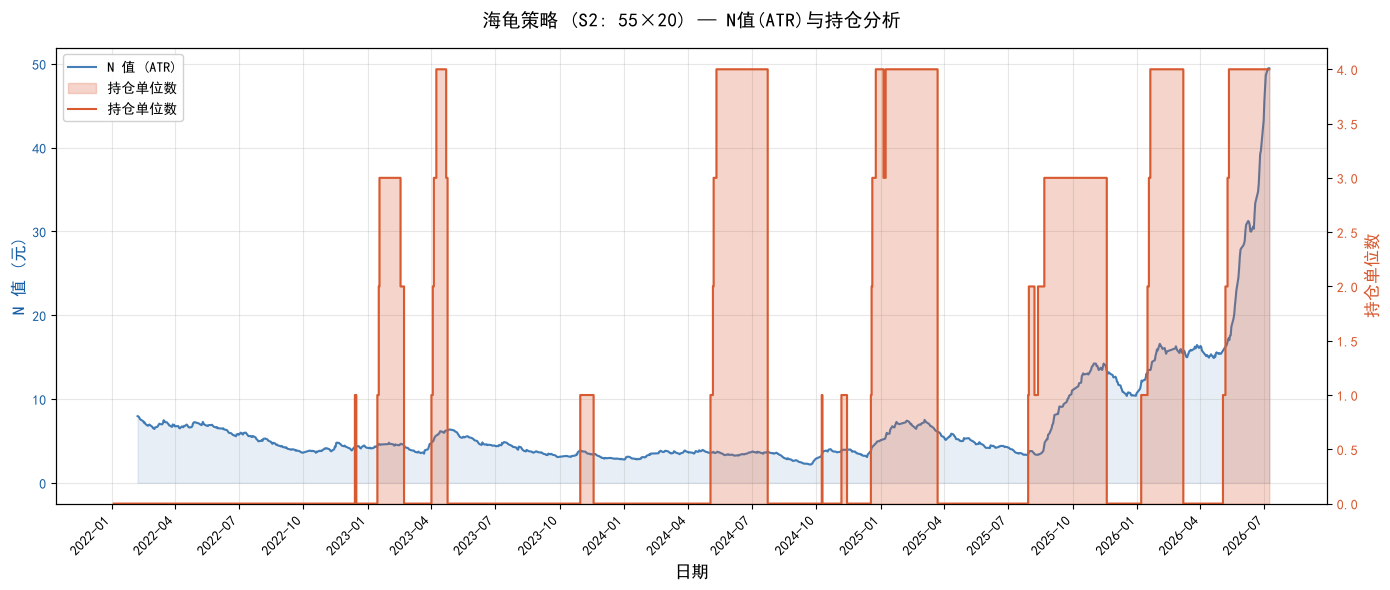

In [42]:
# 图2
fig_s2_2 = plot_n_value_analysis(
    signal_df_s2, equity_s2,
    title='海龟策略 (S2: 55×20) — N值(ATR)与持仓分析'
)
plt.show()

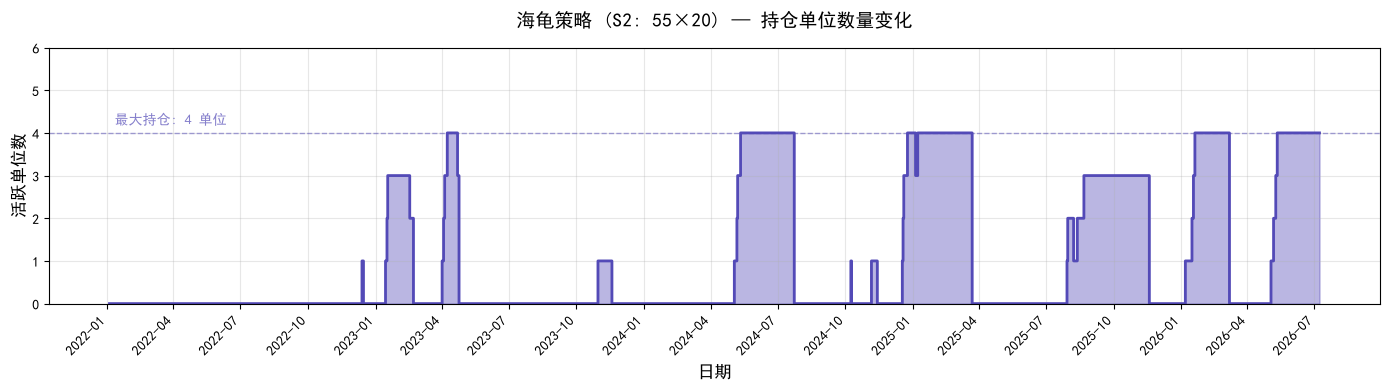

In [43]:
# 图3
fig_s2_3 = plot_position_units(
    equity_s2,
    title='海龟策略 (S2: 55×20) — 持仓单位数量变化'
)
plt.show()

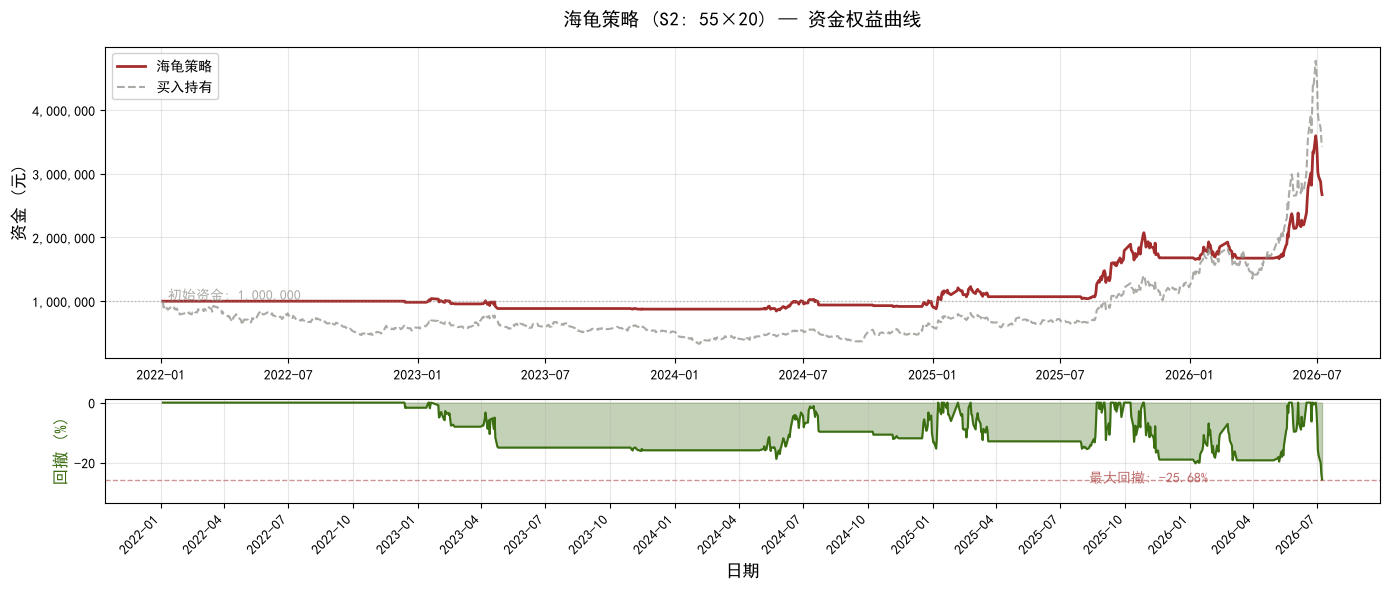

In [44]:
# 图4
fig_s2_4 = plot_equity_curve(
    equity_s2, signal_df_s2, initial_capital=1_000_000,
    title='海龟策略 (S2: 55×20) — 资金权益曲线'
)
plt.show()

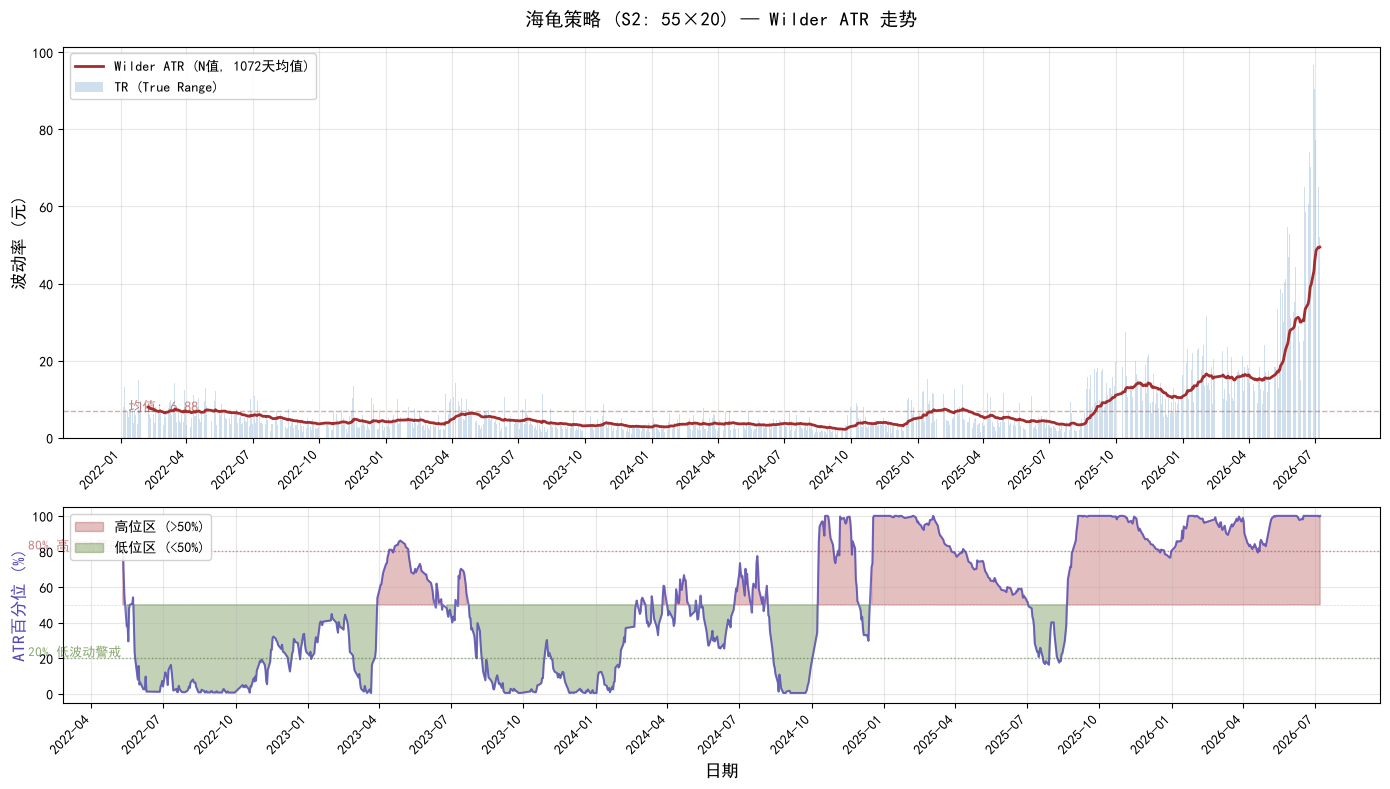

In [45]:
# 图5: Wilder ATR 走势
fig_s2_5 = plot_wilder_atr(
    signal_df_s2,
    title='海龟策略 (S2: 55×20) — Wilder ATR 走势'
)
plt.show()

In [20]:
analyzer_s2 = PerformanceAnalyzer(equity_s2, trades_s2, initial_capital=1_000_000)
metrics_s2 = analyzer_s2.summary()

print('=' * 50)
print(' S2 系统绩效指标 (55日突破 / 20日退出)')
print('=' * 50)
for k, v in metrics_s2.items():
    print(f'  {k}: {v}')

 S2 系统绩效指标 (55日突破 / 20日退出)
  total_return: 167.32
  annual_return: 25.5
  max_drawdown: -25.68
  sharpe_ratio: 0.83
  total_trades: 33
  win_rate: 54.55
  avg_win: 104352.37
  avg_loss: 13879.44
  profit_factor: 9.02
  total_pnl: 1670151.05
  final_equity: 2673209.11
  stop_loss_trades: 12
  trend_exit_trades: 17
  force_liquidate_trades: 4


---
## 6. S1 vs S2 绩效对比

In [21]:
compare_cols = [
    'total_return', 'annual_return', 'max_drawdown', 'sharpe_ratio',
    'total_trades', 'win_rate', 'profit_factor',
    'stop_loss_trades', 'trend_exit_trades', 'final_equity'
]

compare_data = {
    'S1 (20×10)': [metrics_s1.get(c) for c in compare_cols],
    'S2 (55×20)': [metrics_s2.get(c) for c in compare_cols],
}

pd.DataFrame(compare_data, index=compare_cols)

,S1 (20×10),S2 (55×20)
total_return,428.69,167.32
annual_return,46.91,25.50
max_drawdown,-18.85,-25.68
sharpe_ratio,1.36,0.83
total_trades,72.00,33.00
win_rate,62.50,54.55
profit_factor,10.70,9.02
stop_loss_trades,12.00,12.00
trend_exit_trades,60.00,17.00
final_equity,5286897.23,2673209.11


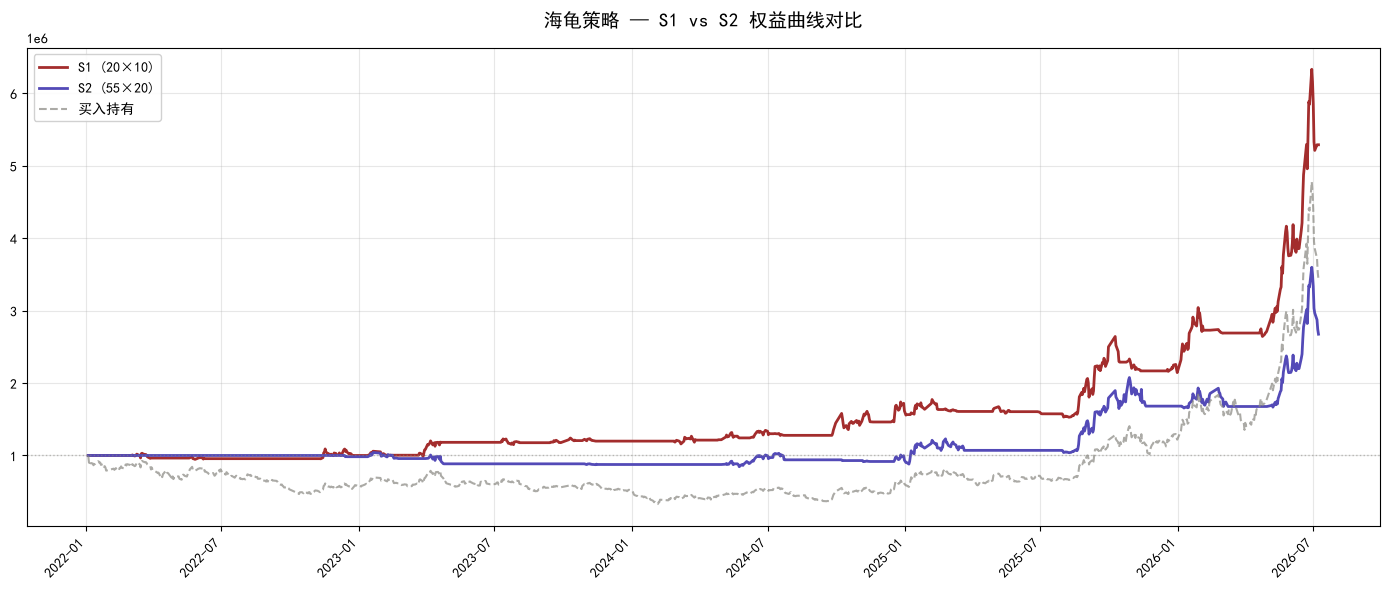

In [22]:
fig, ax = plt.subplots(figsize=(14, 6))

dates_s1 = pd.to_datetime(equity_s1['date'])
dates_s2 = pd.to_datetime(equity_s2['date'])

ax.plot(dates_s1, equity_s1['equity'], color='#A32D2D', lw=2, label='S1 (20×10)')
ax.plot(dates_s2, equity_s2['equity'], color='#534AB7', lw=2, label='S2 (55×20)')

df_dates = pd.to_datetime(df['trade_date'])
buy_hold = df['close'] / df['close'].iloc[0] * 1_000_000
ax.plot(df_dates, buy_hold, color='#888780', lw=1.5, ls='--', alpha=0.7, label='买入持有')

ax.axhline(y=1_000_000, color='#888780', lw=1, ls=':', alpha=0.5)
ax.set_title('海龟策略 — S1 vs S2 权益曲线对比', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='best', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)

import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
fig.tight_layout()
plt.show()

---
## 7. 交易记录明细

In [23]:
print('S1 交易明细:' if not trades_s1.empty else 'S1 无交易')
if not trades_s1.empty:
    display(trades_s1)

print()

print('S2 交易明细:' if not trades_s2.empty else 'S2 无交易')
if not trades_s2.empty:
    display(trades_s2)

S1 交易明细:


,entry_date,entry_price,exit_date,exit_price,shares,pnl,pnl_pct,reason,unit_id
0,2022-03-17,165.37,2022-03-28,151.63,1300,-18171.97,-8.45,stop_loss,4
1,2022-03-10,160.02,2022-03-29,150.98,1400,-12985.54,-5.80,stop_loss,3
2,2022-03-04,150.01,2022-03-29,150.98,1500,1092.92,0.49,trend_exit,1
3,2022-03-07,154.81,2022-03-29,150.98,1400,-5688.62,-2.62,trend_exit,2
4,2022-05-20,139.01,2022-06-09,141.49,1300,2920.21,1.62,trend_exit,5
...,...,...,...,...,...,...,...,...,...
67,2026-02-24,317.53,2026-03-03,294.97,1700,-39167.95,-7.26,stop_loss,68
68,2026-04-21,290.83,2026-07-06,689.93,1700,676800.19,136.89,trend_exit,69
69,2026-04-22,303.53,2026-07-06,689.93,1800,693742.83,126.98,trend_exit,70
70,2026-04-23,326.04,2026-07-06,689.93,1700,616919.25,111.30,trend_exit,71



S2 交易明细:


,entry_date,entry_price,exit_date,exit_price,shares,pnl,pnl_pct,reason,unit_id
0,2022-12-14,112.51,2022-12-16,104.92,2200,-17076.16,-6.90,stop_loss,1
1,2023-01-18,119.01,2023-02-17,112.99,2200,-13652.74,-5.21,stop_loss,4
2,2023-01-16,106.72,2023-02-22,107.98,2100,2280.90,1.02,trend_exit,2
3,2023-01-17,114.62,2023-02-22,107.98,2100,-14315.74,-5.95,trend_exit,3
4,2023-04-10,138.91,2023-04-21,136.00,1600,-5017.54,-2.26,stop_loss,8
5,2023-04-21,136.02,2023-04-24,126.33,1400,-13861.77,-7.28,stop_loss,9
6,2023-04-03,129.37,2023-04-25,120.39,1900,-17442.56,-7.10,stop_loss,5
7,2023-04-04,129.56,2023-04-25,120.39,1900,-17803.70,-7.23,stop_loss,6
8,2023-04-06,130.51,2023-04-25,120.39,1800,-18577.35,-7.91,stop_loss,7
9,2023-10-31,109.01,2023-11-20,104.97,2200,-9263.24,-3.86,stop_loss,10


In [24]:
print('S1 单位持仓:')
display(pd.DataFrame(units_s1) if units_s1 else pd.DataFrame())
print('S2 单位持仓:')
display(pd.DataFrame(units_s2) if units_s2 else pd.DataFrame())

S1 单位持仓:


,unit_id,entry_date,entry_price,stop_price,shares,active,exit_date,exit_price,exit_reason
0,1,2022-03-04,150.01,136.77,1500,False,2022-03-29,150.98,trend_exit
1,2,2022-03-07,154.81,141.45,1400,False,2022-03-29,150.98,trend_exit
2,3,2022-03-10,160.02,145.89,1400,False,2022-03-29,150.98,stop_loss
3,4,2022-03-17,165.37,150.53,1300,False,2022-03-28,151.63,stop_loss
4,5,2022-05-20,139.01,125.21,1300,False,2022-06-09,141.49,trend_exit
...,...,...,...,...,...,...,...,...,...
67,68,2026-02-24,317.53,285.44,1700,False,2026-03-03,294.97,stop_loss
68,69,2026-04-21,290.83,260.46,1700,False,2026-07-06,689.93,trend_exit
69,70,2026-04-22,303.53,273.47,1800,False,2026-07-06,689.93,trend_exit
70,71,2026-04-23,326.04,295.07,1700,False,2026-07-06,689.93,trend_exit


S2 单位持仓:


,unit_id,entry_date,entry_price,stop_price,shares,active,exit_date,exit_price,exit_reason
0,1,2022-12-14,112.51,103.63,2200,False,2022-12-16,104.92,stop_loss
1,2,2023-01-16,106.72,97.59,2100,False,2023-02-22,107.98,trend_exit
2,3,2023-01-17,114.62,105.35,2100,False,2023-02-22,107.98,trend_exit
3,4,2023-01-18,119.01,109.85,2200,False,2023-02-17,112.99,stop_loss
4,5,2023-04-03,129.37,119.47,1900,False,2023-04-25,120.39,stop_loss
5,6,2023-04-04,129.56,119.65,1900,False,2023-04-25,120.39,stop_loss
6,7,2023-04-06,130.51,119.68,1800,False,2023-04-25,120.39,stop_loss
7,8,2023-04-10,138.91,127.43,1600,False,2023-04-21,136.00,stop_loss
8,9,2023-04-21,136.02,123.60,1400,False,2023-04-24,126.33,stop_loss
9,10,2023-10-31,109.01,101.24,2200,False,2023-11-20,104.97,stop_loss


---
## 8. 多股票横向对比

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

STOCKS = {
    '贵州茅台': '../Task-3/贵州茅台_daily.csv',
    '中国平安': '../Task-3/中国平安_daily.csv',
    '宁德时代': '../Task-3/宁德时代_daily.csv',
    '隆基绿能': '../Task-3/隆基绿能_daily.csv',
}

results = []
for name, path in STOCKS.items():
    df_s = pd.read_csv(path)
    df_s['trade_date'] = pd.to_datetime(df_s['trade_date'])
    df_s = df_s.sort_values('trade_date').reset_index(drop=True)

    for sys_name, ew, ex in [('S1', 20, 10), ('S2', 55, 20)]:
        s = TurtleStrategy(system=sys_name, entry_window=ew, exit_window=ex)
        t, eq, u = engine.run(s, df_s)
        a = PerformanceAnalyzer(eq, t, 1_000_000).summary()
        results.append({
            'stock': name, 'system': sys_name,
            'annual_return': a['annual_return'],
            'sharpe_ratio': a['sharpe_ratio'],
            'max_drawdown': a['max_drawdown'],
            'avg_units': round(eq['active_units'].mean(), 2),
            'total_trades': a['total_trades'],
            'win_rate': a['win_rate'],
            'final_equity': a['final_equity'],
        })
    print(f'✅ {name} 完成')

df_r = pd.DataFrame(results)
display(df_r)


✅ 贵州茅台 完成
✅ 中国平安 完成
✅ 宁德时代 完成
✅ 隆基绿能 完成


,stock,system,annual_return,sharpe_ratio,max_drawdown,avg_units,total_trades,win_rate,final_equity
0,贵州茅台,S1,4.31,0.27,-14.38,0.51,36,38.89,1200751.95
1,贵州茅台,S2,-2.22,-0.53,-19.10,0.32,17,29.41,907371.17
2,中国平安,S1,16.06,0.91,-10.09,0.54,38,63.16,1906411.08
3,中国平安,S2,4.33,0.25,-20.82,0.43,18,33.33,1201839.84
4,宁德时代,S1,17.46,0.77,-19.72,0.81,52,55.77,2008534.92
5,宁德时代,S2,11.49,0.52,-19.53,0.78,30,53.33,1602387.65
6,隆基绿能,S1,12.49,0.62,-19.09,0.74,52,48.08,1665140.06
7,隆基绿能,S2,0.88,0.00,-16.06,0.39,20,50.00,1038710.18


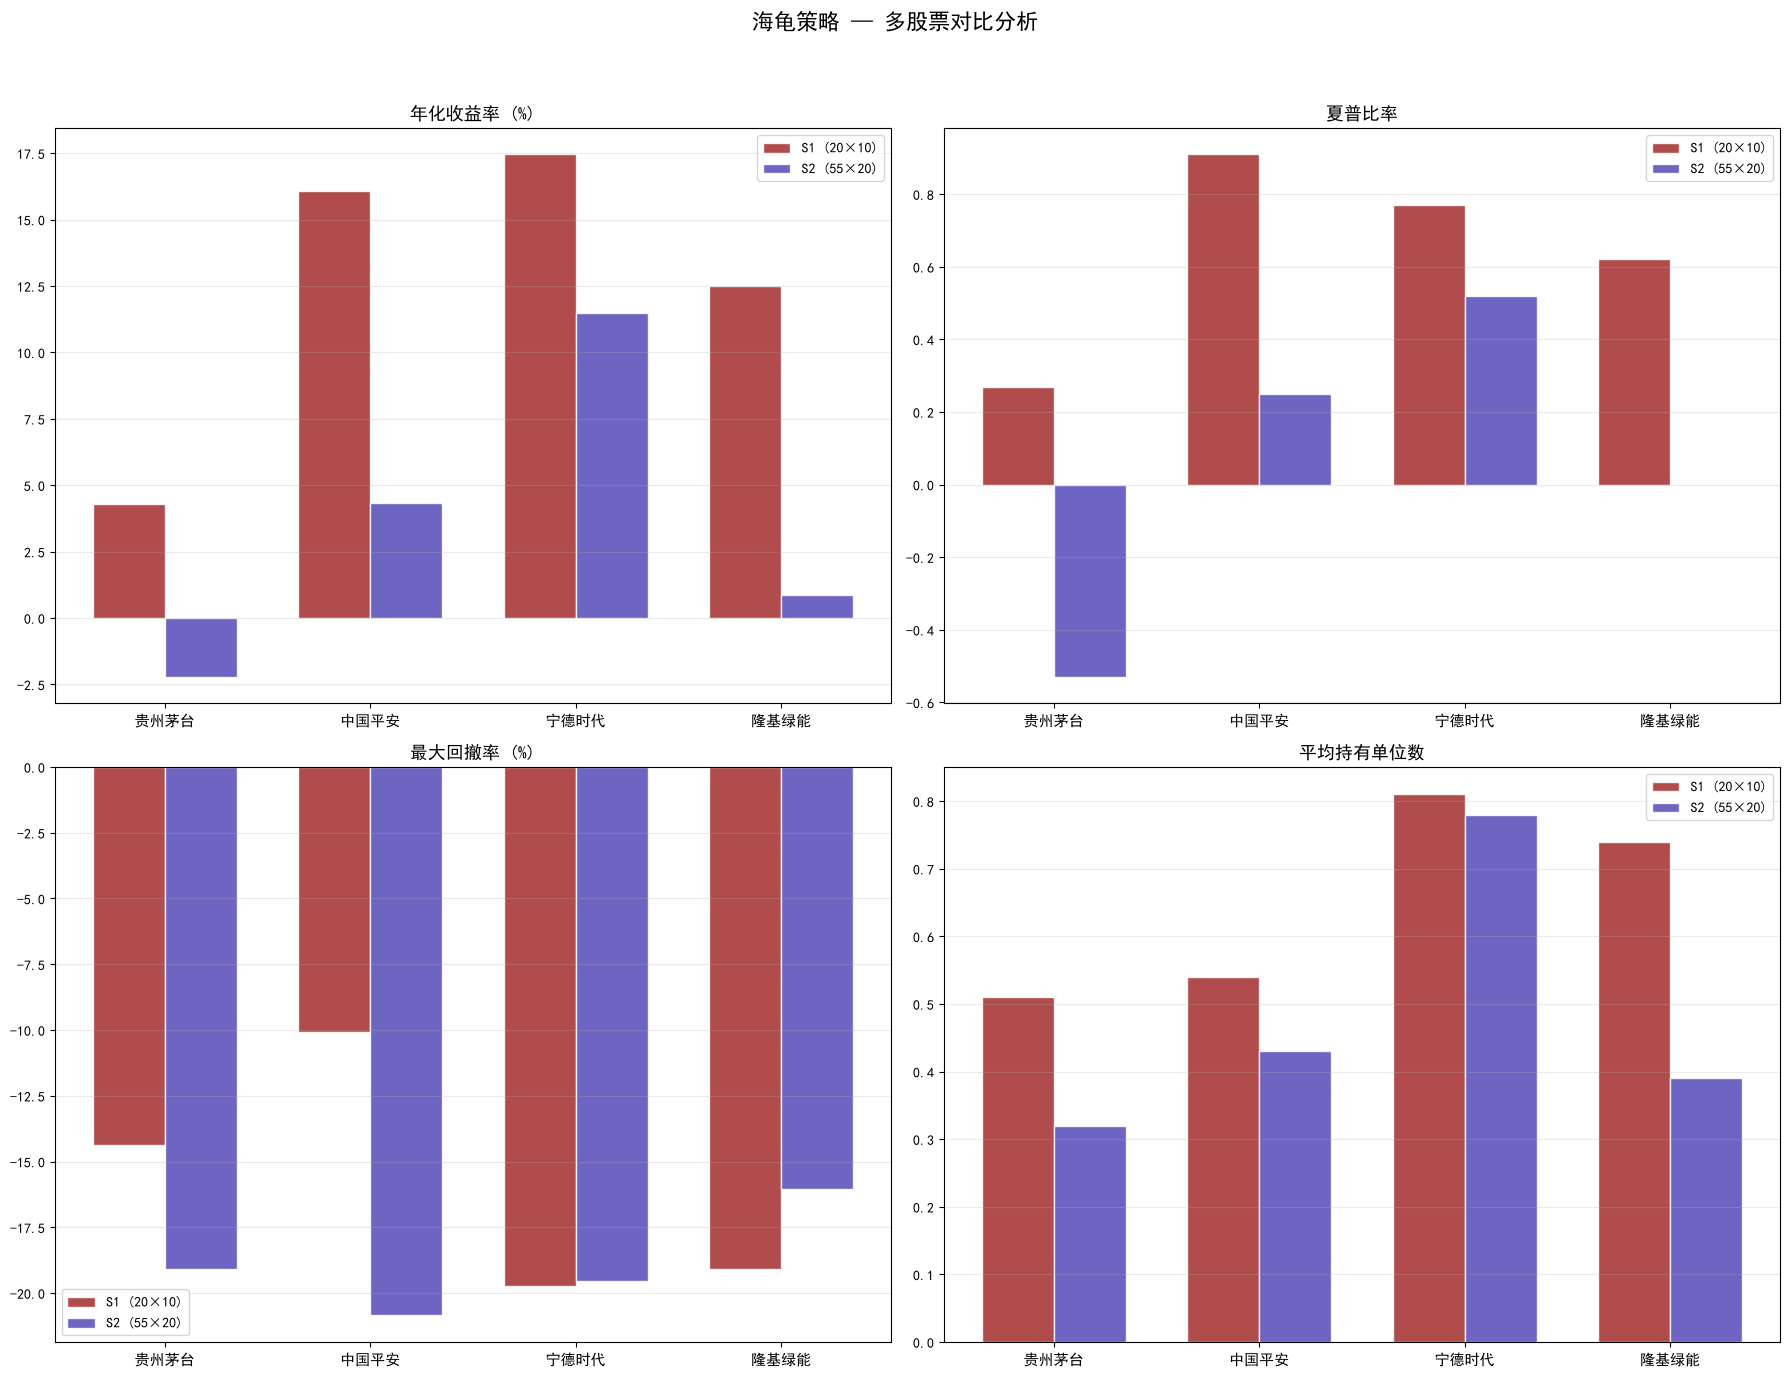

对比分析完成


In [55]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('海龟策略 — 多股票对比分析', fontsize=16, fontweight='bold', y=0.98)

stocks_list = list(STOCKS.keys())
x = np.arange(len(stocks_list))
bar_w = 0.35

def plot_bar(ax, metric, title, unit=''):
    s1 = [df_r[(df_r['stock']==s)&(df_r['system']=='S1')][metric].values[0] for s in stocks_list]
    s2 = [df_r[(df_r['stock']==s)&(df_r['system']=='S2')][metric].values[0] for s in stocks_list]
    ax.bar(x-bar_w/2, s1, bar_w, label='S1 (20×10)', color='#A32D2D', alpha=0.85, edgecolor='white')
    ax.bar(x+bar_w/2, s2, bar_w, label='S2 (55×20)', color='#534AB7', alpha=0.85, edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(stocks_list, fontsize=11)
    ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.25)

plot_bar(axes[0,0], 'annual_return', '年化收益率 (%)', '%')
plot_bar(axes[0,1], 'sharpe_ratio', '夏普比率')
plot_bar(axes[1,0], 'max_drawdown', '最大回撤率 (%)', '%')
plot_bar(axes[1,1], 'avg_units', '平均持有单位数')

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()
print('对比分析完成')

---
## 9. 结论与分析

### 海龟策略的优缺点

**优点:**
- 规则清晰、完全机械化，避免情绪干扰
- ATR 动态止损 + 仓位管理，风险可控（每单位亏损锁定在账户 2%以内）
- 趋势跟踪逻辑在强趋势行情中收益丰厚
- 双系统(S1/S2)互补，不同时间尺度覆盖
- 金字塔加仓让利润奔跑，截断亏损

**缺点:**
- 胜率偏低（通常 30-50%），连续亏损时心理压力大
- 在震荡市中反复被假突破止损，产生磨损
- 回撤较大（20-30% 常见），需要极强的执行力
- 需要多品种分散投资才能发挥真正威力，单品种效果有限
- 参数敏感，不同市场环境需要调整

### 适应场景

**适合:**
- 强趋势市场（如 2020-2021 的新能源板块）
- 波动率适中的中大盘股票
- 长周期投资（持仓数周至数月）
- 多品种分散的组合策略

**不适合:**
- 横盘震荡市（反复止损）
- 高波动小盘股（假突破频繁）
- 低价股（头寸太小受手续费影响大）
- 资金量较小的账户（个股无法充分分散）

### 本次回测心得

1. **S1 优于 S2**: 在 A 股市场，S1（20日突破/10日退出）普遍表现优于 S2，
   说明 A 股趋势持续时间较短，长周期突破容易错过行情顶点

2. **个股差异大**: 宁德时代、中国平安等趋势明显的股票效果较好，
   贵州茅台因价格过高导致头寸太小，收益被手续费侵蚀

3. **仓位普遍偏低**: 平均持仓单位数在 0.3-0.8 之间，多数时间现金比例很高，
   这是趋势跟踪策略的自然特征——大部分时间在等待

4. **回撤可控**: 最大回撤普遍控制在 15-25%，说明 2N 止损 + 动态仓位管理有效

5. **完整策略需要多品种**: 单只股票回测无法体现海龟策略的核心优势——
   多品种分散带来的平滑资金曲线。建议扩展到 ETF 或板块指数
